In [1]:
%pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\komal\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("images", exist_ok=True)   # folder for saved charts

df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
print(df.shape)
df.columns.tolist()

(50000, 24)


['Order_ID',
 'Order_Date',
 'Order_Hour',
 'Day_of_Week',
 'Is_Weekend',
 'Is_Festival',
 'Weather',
 'Pickup_Zone',
 'Dropoff_Zone',
 'Vehicle_Type',
 'Rider_Experience_Years',
 'Rider_Rating',
 'Restaurant_Rating',
 'Cuisine_Type',
 'Order_Items',
 'Restaurant_Load',
 'Preparation_Time_Min',
 'Road_Distance_km',
 'Delivery_Distance_Category',
 'Traffic_Level',
 'Number_of_Signals',
 'Average_Speed_kmph',
 'Delivery_Priority',
 'Time_taken_min']

In [3]:
df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


This is a snippet of the data that I will analyse in my project.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  str    
 1   Order_Date                  50000 non-null  str    
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  str    
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  str    
 7   Pickup_Zone                 50000 non-null  str    
 8   Dropoff_Zone                50000 non-null  str    
 9   Vehicle_Type                50000 non-null  str    
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                50000 non-null

In [5]:
df.describe(include='all')

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
count,50000,50000,50000.000000,50000,50000.000000,50000.000000,50000,50000,50000,50000,...,50000.000000,50000,50000.00000,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000.000000
unique,50000,365,NaN,7,NaN,NaN,5,5,5,4,...,NaN,3,NaN,NaN,3,4,NaN,NaN,3,NaN
top,ORD000001,2025-02-12,NaN,Tuesday,NaN,NaN,Clear,Residential,Residential,Bike,...,NaN,Low,NaN,NaN,Long,Low,NaN,NaN,Normal,NaN
freq,1,170,NaN,7264,NaN,NaN,23992,15786,16106,22943,...,NaN,17751,NaN,NaN,47238,32567,NaN,NaN,37065,NaN
mean,NaN,NaN,13.847700,NaN,0.283600,0.049100,NaN,NaN,NaN,NaN,...,2.652740,NaN,24.03118,26.201744,NaN,NaN,9.728920,31.759634,NaN,83.868980
std,NaN,NaN,5.525291,NaN,0.450749,0.216079,NaN,NaN,NaN,NaN,...,1.590359,NaN,8.34877,12.620079,NaN,NaN,4.330849,9.510842,NaN,35.426899
min,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,...,1.000000,NaN,5.00000,0.080000,NaN,NaN,2.000000,8.000000,NaN,10.000000
25%,NaN,NaN,10.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,...,1.000000,NaN,18.00000,16.330000,NaN,NaN,6.000000,25.300000,NaN,58.000000
50%,NaN,NaN,14.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,...,2.000000,NaN,24.00000,25.620000,NaN,NaN,9.000000,33.100000,NaN,78.000000
75%,NaN,NaN,19.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,...,4.000000,NaN,30.00000,35.480000,NaN,NaN,14.000000,39.600000,NaN,102.000000


In [6]:
df.isnull().sum()

Order_ID                      0
Order_Date                    0
Order_Hour                    0
Day_of_Week                   0
Is_Weekend                    0
Is_Festival                   0
Weather                       0
Pickup_Zone                   0
Dropoff_Zone                  0
Vehicle_Type                  0
Rider_Experience_Years        0
Rider_Rating                  0
Restaurant_Rating             0
Cuisine_Type                  0
Order_Items                   0
Restaurant_Load               0
Preparation_Time_Min          0
Road_Distance_km              0
Delivery_Distance_Category    0
Traffic_Level                 0
Number_of_Signals             0
Average_Speed_kmph            0
Delivery_Priority             0
Time_taken_min                0
dtype: int64

In [7]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min'],
      dtype='str')

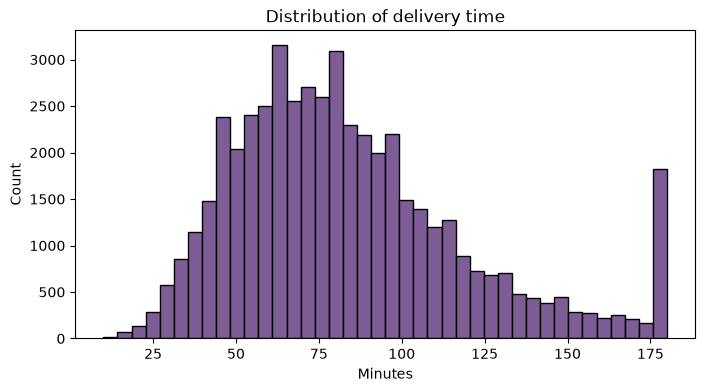

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Time_taken_min"], bins=40, facecolor="#7D5D96")
plt.title("Distribution of delivery time")
plt.xlabel("Minutes")
plt.savefig("images/delivery_time_distribution.png", dpi=150, bbox_inches="tight")

plt.show()


The average delivery time for most orders vary from 60-80 mins.

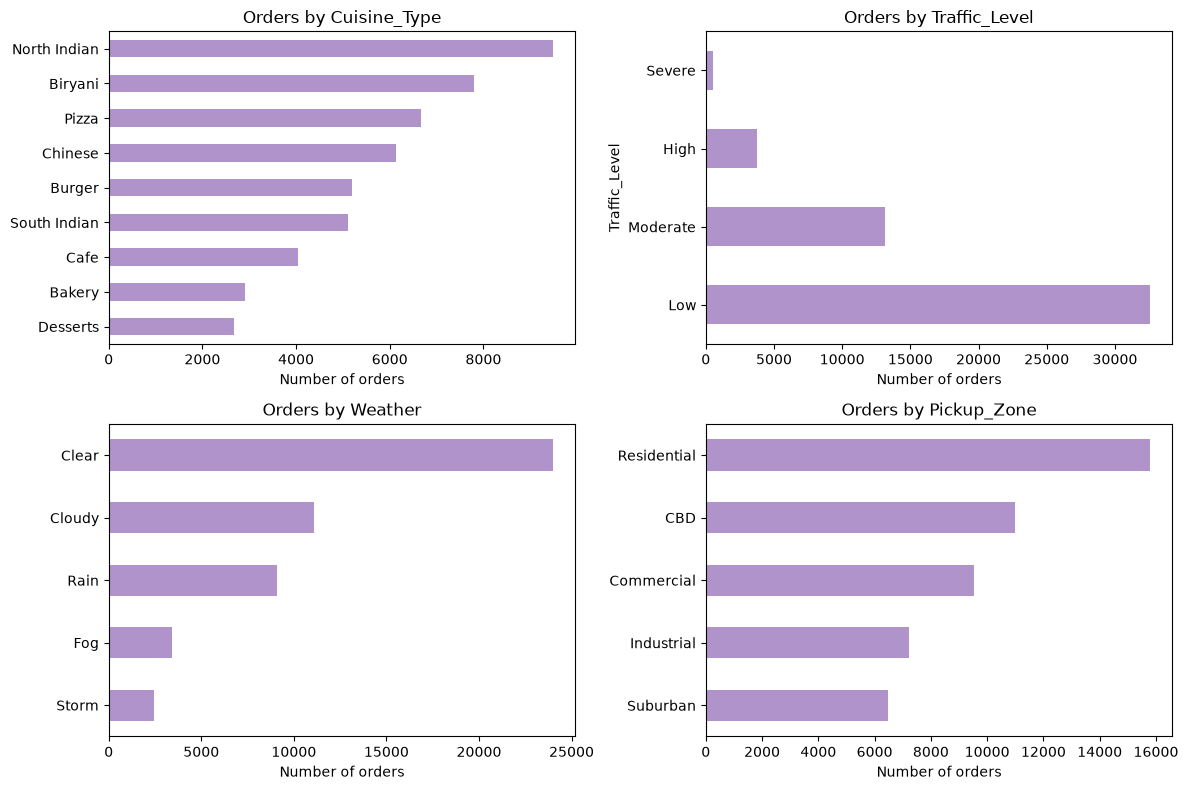

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ["Cuisine_Type", "Traffic_Level", "Weather", "Pickup_Zone"]):
    df[col].value_counts().plot(kind="barh", ax=ax, facecolor="#B193CC")
    ax.set_title(f"Orders by {col}")
    
    ax.set_ylabel("") 
    ax.invert_yaxis()
    if col == "Traffic_Level":
      df[col].value_counts().reindex(["Low", "Moderate", "High", "Severe"]).plot(kind="barh", ax=ax, facecolor="#B193CC")
    ax.set_xlabel("Number of orders")
plt.tight_layout()
plt.savefig("images/data_overview.png", dpi=150, bbox_inches="tight")
plt.show()

These plots gives you an idea about what kinf of cuisines are ordered most, how severe traffic is and the weather conditions. 
The Pickup Zone plot is purposefully mentioned here as it helps in finding a key insight later.

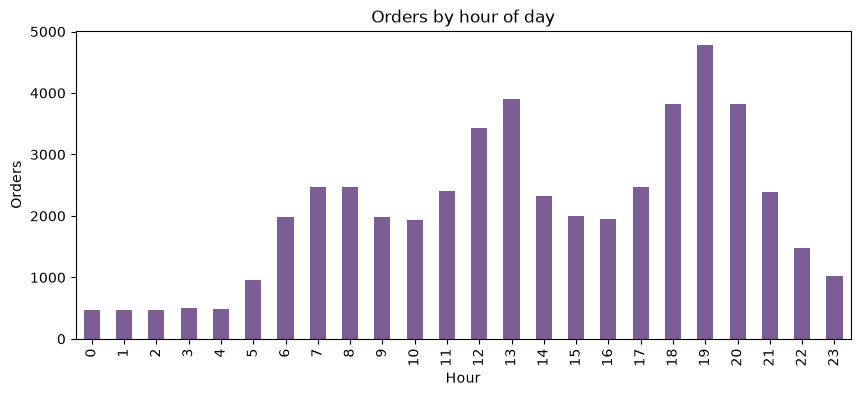

In [25]:
df["Order_Hour"].value_counts().sort_index().plot(kind="bar", figsize=(10, 4), facecolor="#7D5D96")
plt.title("Orders by hour of day")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.savefig("images/orders_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

Most of the delivery takes place in two time frames :- 
1.
2.
there will be an extensive analysis for these two time frames over the conditons of food delivery, the causes for any delay and how to improve.

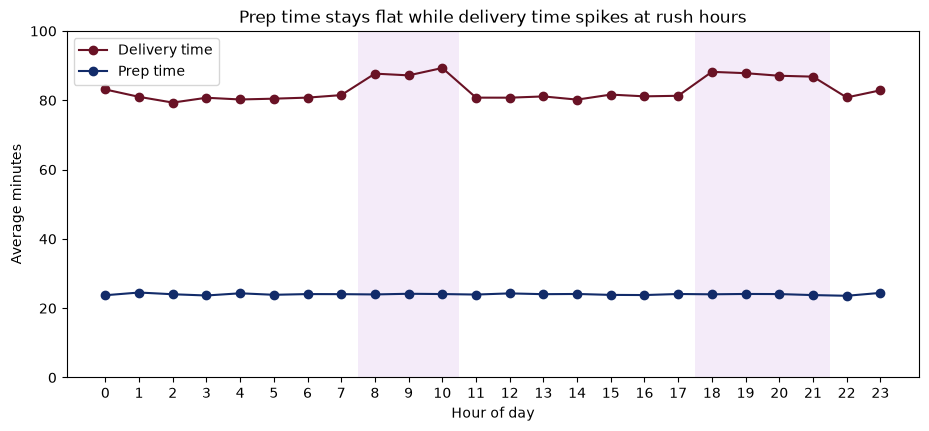

In [29]:
hourly = df.groupby("Order_Hour").agg(
    orders=("Time_taken_min", "size"),
    delivery=("Time_taken_min", "mean"),
    prep=("Preparation_Time_Min", "mean"),
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hourly.index, hourly["delivery"], color="#691225", marker="o", label="Delivery time")
ax.plot(hourly.index, hourly["prep"], color="#122B69", marker="o", label="Prep time")

# shade the two rush windows
ax.axvspan(7.5, 10.5, facecolor="#B97FDB", alpha=0.15)
ax.axvspan(17.5, 21.5, facecolor="#B97FDB", alpha=0.15)

ax.set_ylim(0, 100)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average minutes")
ax.set_title("Prep time stays flat while delivery time spikes at rush hours")
ax.legend()

plt.savefig("images/prep_vs_delivery_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

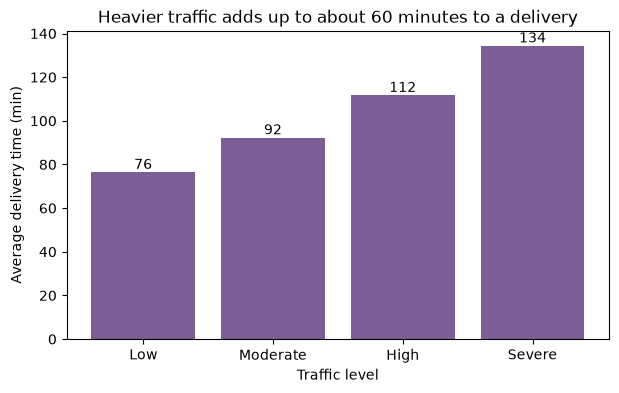

In [30]:
order = ["Low", "Moderate", "High", "Severe"]

traffic = df.groupby("Traffic_Level")["Time_taken_min"].mean().reindex(order)

plt.figure(figsize=(7, 4))
bars = plt.bar(traffic.index, traffic.values, facecolor="#7D5D96")
plt.bar_label(bars, fmt="%.0f")
plt.xlabel("Traffic level")
plt.ylabel("Average delivery time (min)")
plt.title("Heavier traffic adds up to about 60 minutes to a delivery")
plt.savefig("images/delivery_by_traffic.png", dpi=150, bbox_inches="tight")
plt.show()

Average delivery time rises from about 75 minutes in Low traffic to about 135 in Severe traffic.

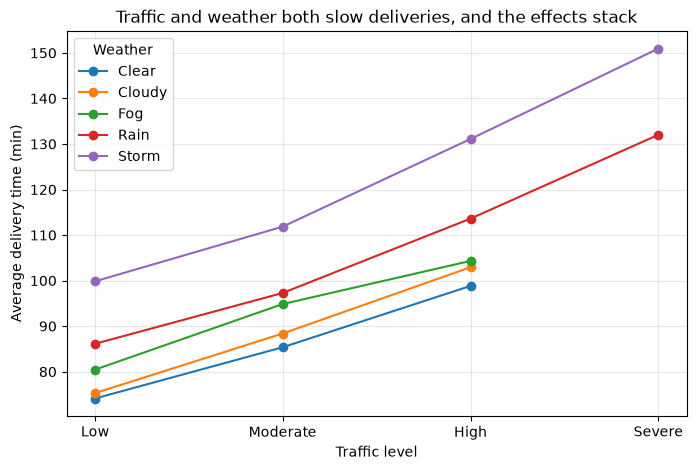

In [13]:
weather_order = ["Clear", "Cloudy", "Fog", "Rain", "Storm"]

g = df.groupby(["Weather", "Traffic_Level"])["Time_taken_min"].agg(["mean", "size"])
g.loc[g["size"] < 50, "mean"] = None      # hide cells with too few orders
table = g["mean"].unstack().reindex(index=weather_order, columns=order)

plt.figure(figsize=(8, 5))
for w in weather_order:
    plt.plot(order, table.loc[w], marker="o", label=w)
plt.xlabel("Traffic level")
plt.ylabel("Average delivery time (min)")
plt.title("Traffic and weather both slow deliveries, and the effects stack")
plt.legend(title="Weather")
plt.grid(alpha=0.3)
plt.savefig("images/delivery_traffic_weather.png", dpi=150, bbox_inches="tight")
plt.show()

Weather shifts the whole line upward. A storm adds about 26 minutes even in Low traffic, so the best case (Clear, Low traffic) is 74 minutes and a Storm in High traffic is 131.

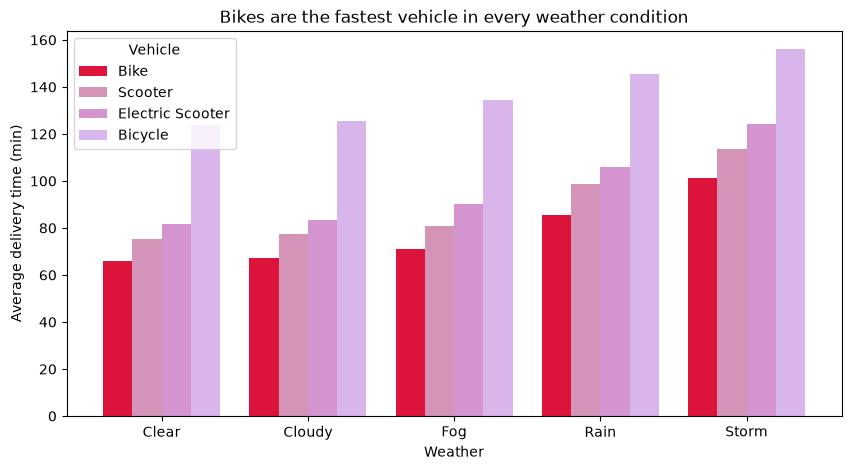

In [35]:
weather_order = ["Clear", "Cloudy", "Fog", "Rain", "Storm"]

veh = (df.groupby(["Weather", "Vehicle_Type"])["Time_taken_min"]
         .mean()
         .unstack()
         .reindex(weather_order))

cols = ["Bike", "Scooter", "Electric Scooter", "Bicycle"]
facecolors = {
    "Bike": "crimson",
    "Scooter": "#D494B8",
    "Electric Scooter": "#D494D0",
    "Bicycle": "#D8B5EB"
}

veh[cols].plot(kind="bar", figsize=(10, 5),
               color=[facecolors[c] for c in cols], width=0.8)
plt.xlabel("Weather")
plt.ylabel("Average delivery time (min)")
plt.title("Bikes are the fastest vehicle in every weather condition")
plt.xticks(rotation=0)
plt.legend(title="Vehicle")
plt.savefig("images/vehicle_by_weather.png", dpi=150, bbox_inches="tight")
plt.show()

Assign Bikes first to long routes and bad-weather orders, and keep Bicycles for short trips.

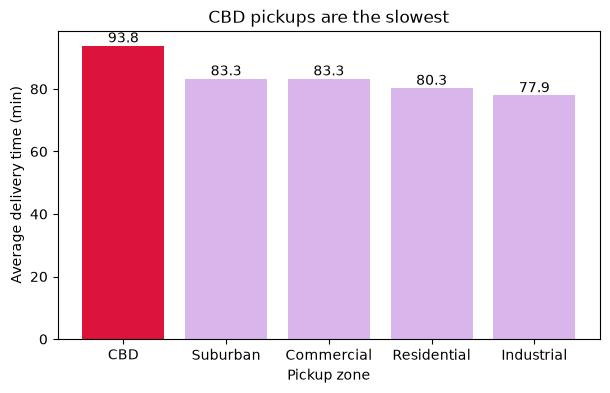

In [36]:
zone = df.groupby("Pickup_Zone")["Time_taken_min"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(zone.index, zone.values,
               facecolor=["crimson" if z == "CBD" else "#D8B5EB" for z in zone.index])
plt.bar_label(bars, fmt="%.1f")
plt.xlabel("Pickup zone")
plt.ylabel("Average delivery time (min)")
plt.title("CBD pickups are the slowest")
plt.savefig("images/delivery_by_pickup_zone.png", dpi=150, bbox_inches="tight")
plt.show()

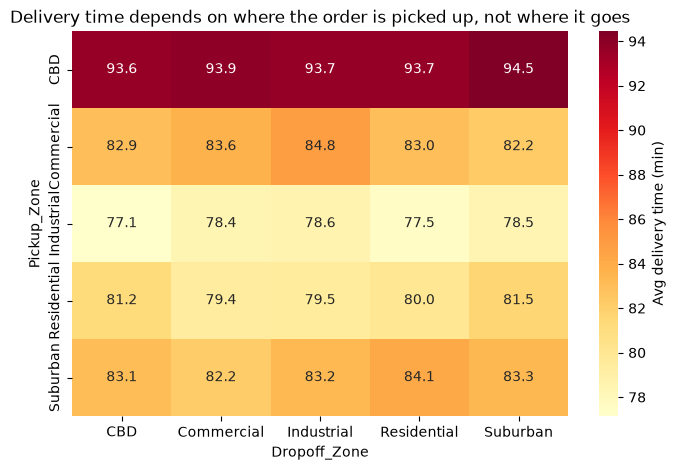

In [16]:
route = df.pivot_table(index="Pickup_Zone", columns="Dropoff_Zone",
                       values="Time_taken_min", aggfunc="mean")

plt.figure(figsize=(8, 5))
sns.heatmap(route, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Avg delivery time (min)"})
plt.title("Delivery time depends on where the order is picked up, not where it goes")
plt.savefig("images/heatmap_pickup_dropoff.png", dpi=150, bbox_inches="tight")
plt.show()

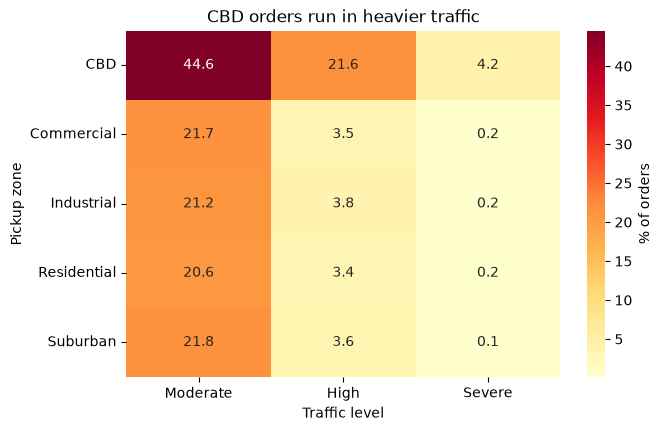

In [17]:
traffic_order = ["Moderate", "High", "Severe"]

share = (pd.crosstab(df["Pickup_Zone"], df["Traffic_Level"], normalize="index") * 100)[traffic_order]
share = share.reindex(["CBD", "Commercial", "Industrial", "Residential", "Suburban"])

plt.figure(figsize=(7, 4.5))
ax = sns.heatmap(share, annot=True, fmt=".1f", cmap="YlOrRd",
                 cbar_kws={"label": "% of orders"})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_ylabel("Pickup zone")
ax.set_xlabel("Traffic level")
plt.title("CBD orders run in heavier traffic")
plt.savefig("images/heatmap_zone_traffic.png", dpi=150, bbox_inches="tight")
plt.show()

Pickup_Zone
CBD            26.4
Commercial     23.3
Industrial     22.4
Residential    23.3
Suburban       24.6
Name: Preparation_Time_Min, dtype: float64


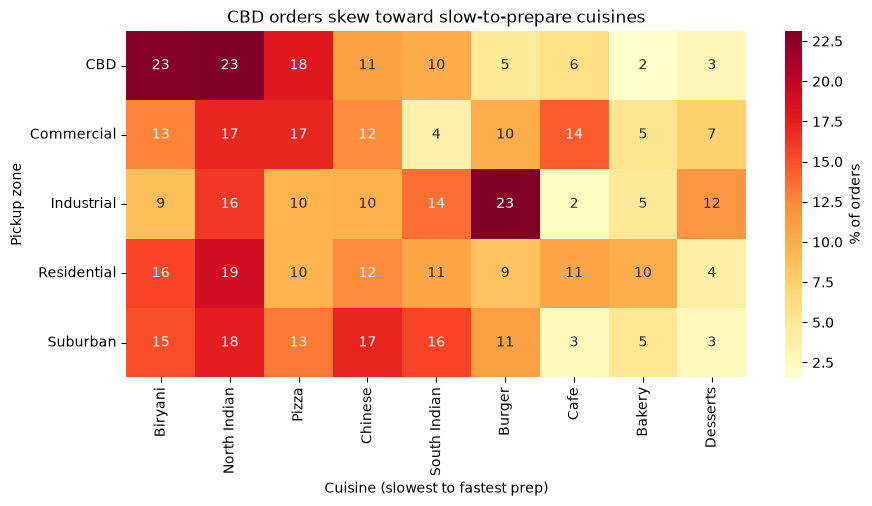

In [18]:
# prep time by pickup zone
print(df.groupby("Pickup_Zone")["Preparation_Time_Min"].mean().round(1))

# cuisine mix per zone (% of orders)
mix = pd.crosstab(df["Pickup_Zone"], df["Cuisine_Type"], normalize="index") * 100
order = df.groupby("Cuisine_Type")["Preparation_Time_Min"].mean().sort_values(ascending=False).index
mix = mix[order].reindex(["CBD", "Commercial", "Industrial", "Residential", "Suburban"])

plt.figure(figsize=(10, 4.5))
ax = sns.heatmap(mix, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "% of orders"})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xlabel("Cuisine (slowest to fastest prep)")
ax.set_ylabel("Pickup zone")
plt.title("CBD orders skew toward slow-to-prepare cuisines")
plt.savefig("images/heatmap_zone_cuisine.png", dpi=150, bbox_inches="tight")
plt.show()

CBD pickups average 93.8 min, about 13 min more than other zones. Two things add up:

- Traffic (the main cause, about 11 min): 26% of CBD orders ran in High or Severe traffic against about 4% elsewhere, and riders averaged 28.4 km/h against 32.7.
- Preparation time (about 3 min): CBD orders average 26.4 min of prep against about 23 elsewhere. This is not because CBD kitchens are busier or orders larger. Biryani, North Indian and Pizza, the three slowest cuisines, make up about 64% of CBD orders against 44% in Residential.

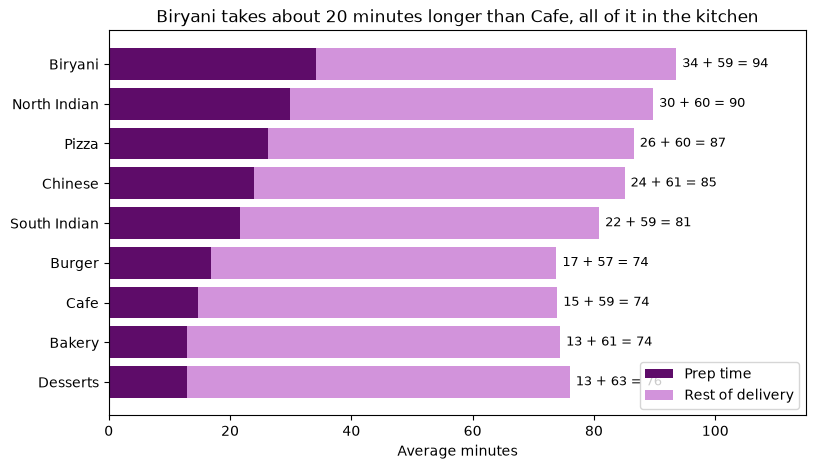

In [19]:
cu = df.groupby("Cuisine_Type").agg(prep=("Preparation_Time_Min", "mean"),
                                    total=("Time_taken_min", "mean"))
cu["rest"] = cu["total"] - cu["prep"]
cu = cu.sort_values("prep")          # slowest ends up at the top of a barh chart

plt.figure(figsize=(9, 5))
plt.barh(cu.index, cu["prep"], facecolor="#5E0C69", label="Prep time")
plt.barh(cu.index, cu["rest"], left=cu["prep"], facecolor="#D293DB", label="Rest of delivery")
for i, (p, t) in enumerate(zip(cu["prep"], cu["total"])):
    plt.text(t + 1, i, f"{p:.0f} + {t - p:.0f} = {t:.0f}", va="center", fontsize=9)
plt.xlabel("Average minutes")
plt.xlim(0, 115)
plt.title("Biryani takes about 20 minutes longer than Cafe, all of it in the kitchen")
plt.legend(loc="lower right")
plt.savefig("images/cuisine_prep_vs_rest.png", dpi=150, bbox_inches="tight")
plt.show()

Biryani (34 min), North Indian (30) and Pizza (26) take longest to prepare, while Cafe, Desserts and Bakery take under 15. Time after prep is about 59 to 61 minutes for nearly every cuisine, so the whole gap between cuisines is in the kitchen: a Biryani order takes about 20 minutes longer to deliver than a Cafe order.